### init

In [47]:
import os
import socket

from matplotlib import pyplot as plt
import pandas as pd

machine_name = socket.gethostname()

### add new from Downloads/

In [86]:
path = f'../recordings/timetraces/{machine_name}'

In [87]:
# append & remove csv files after download
!cat ~/Downloads/timestamps_animation.csv >> $path/timestamps_animation.csv && rm ~/Downloads/timestamps_animation.csv
!cat ~/Downloads/timestamps_signals.csv >> $path/timestamps_signals.csv && rm ~/Downloads/timestamps_signals.csv

In [88]:
!ls -lh $path

total 96
-rw-r--r--  1 andreassteiner  staff   7.9K Nov 15 11:04 animator_in.txt
-rw-r--r--  1 andreassteiner  staff   7.9K Nov 15 11:04 animator_out.txt
-rw-r--r--  1 andreassteiner  staff   7.9K Nov 15 11:04 recorder.txt
-rw-r--r--  1 andreassteiner  staff    14K Nov 15 11:05 timestamps_animation.csv
-rw-r--r--  1 andreassteiner  staff   7.9K Nov 15 11:05 timestamps_signals.csv


### analysis

In [80]:
def load(name):
    path = f'../recordings/timetraces/{name}'
    return pd.concat([
        pd.read_csv(f'{path}/{filename}', names=[filename.split('.')[0]])
        for filename in os.listdir(path)
    ], axis=1).astype('float')

In [70]:
!ls ../recordings/timetraces/

cervelat_notf cervelat_tf


#### the cost of tf

In [89]:
df_tf = load('cervelat_tf')
df_notf = load('cervelat_notf')

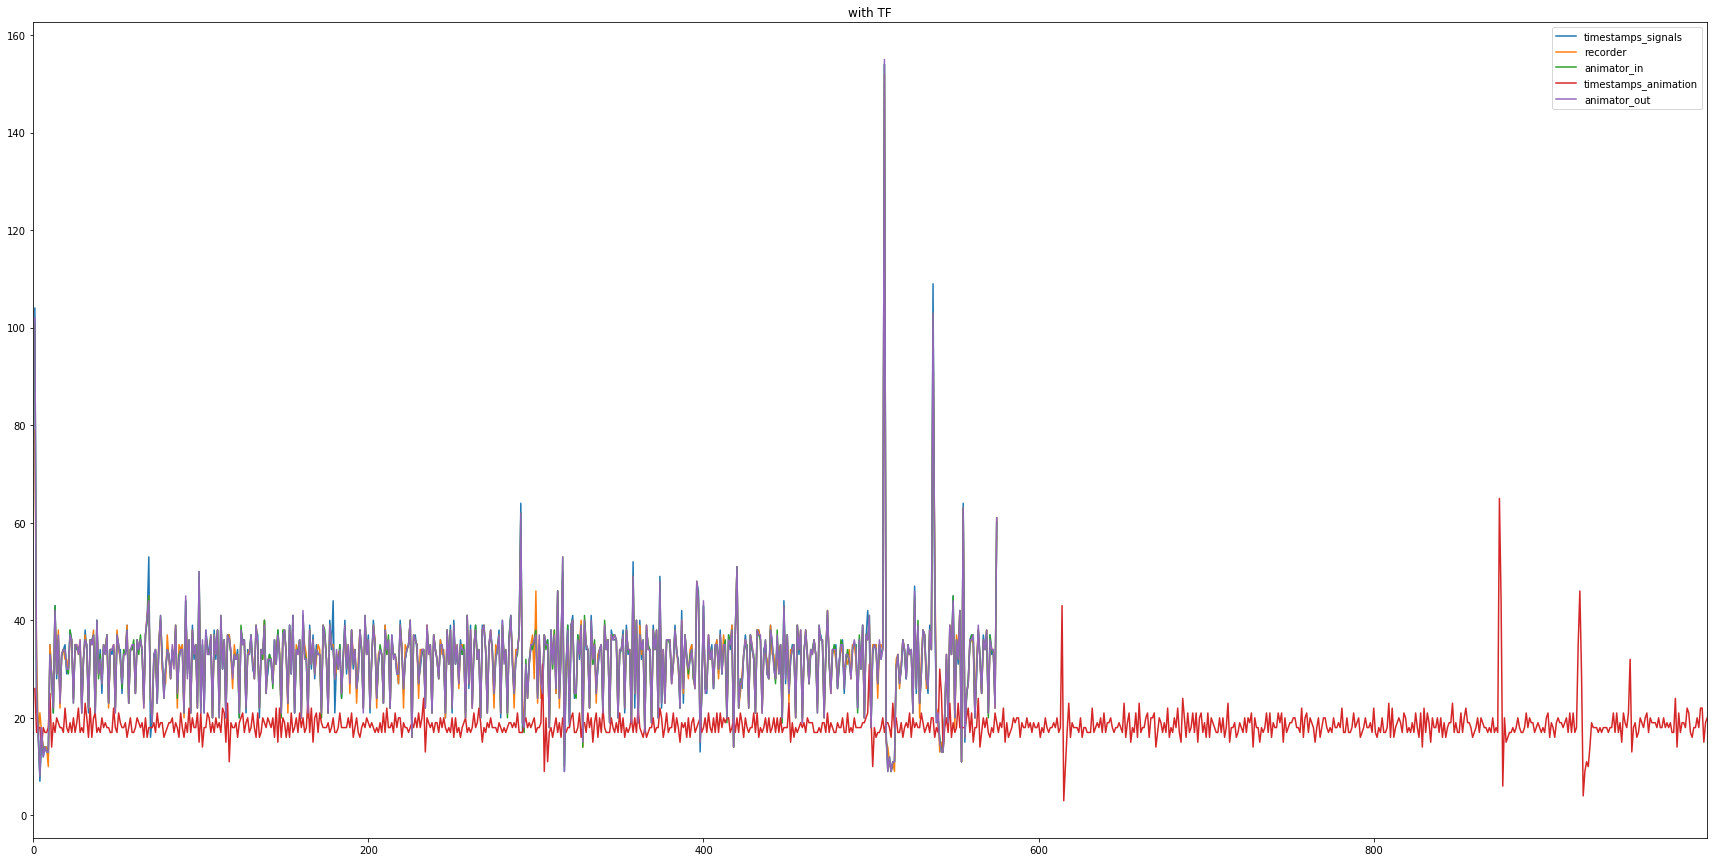

In [91]:
# up to 160ms due to tensorflow
plt.figure(figsize=(30, 15))
df_tf.iloc[:1000].diff().plot(ax=plt.gca(), title='with TF');

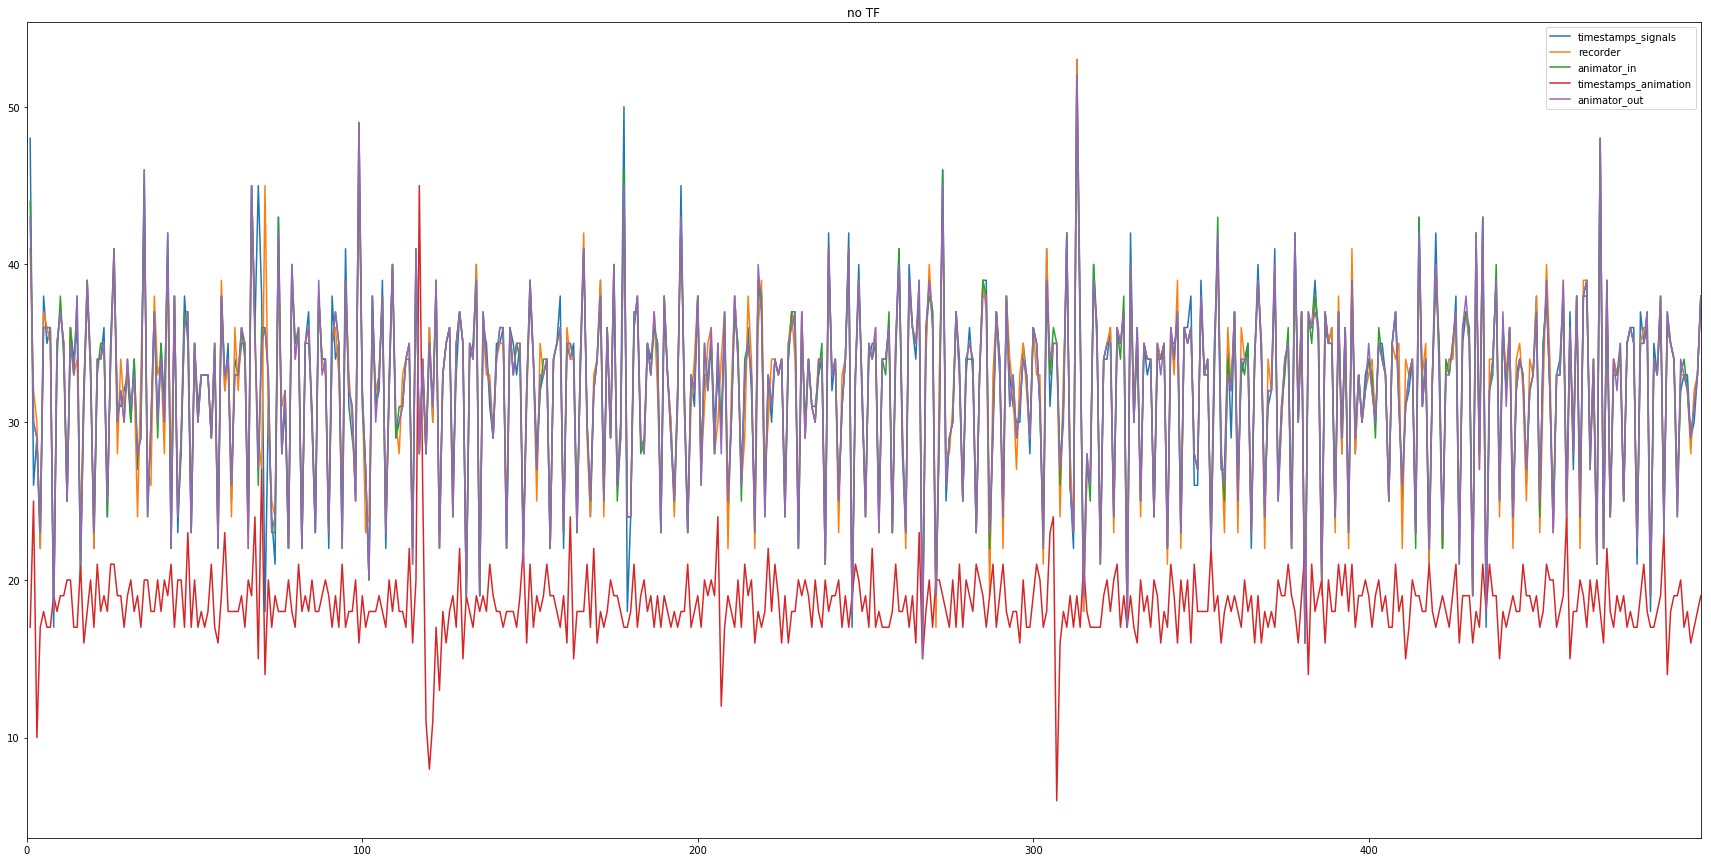

In [84]:
# deactivating tf reduces to <50ms consistently
plt.figure(figsize=(30, 15))
df_notf.iloc[:500].diff().plot(ax=plt.gca(), title='no TF');

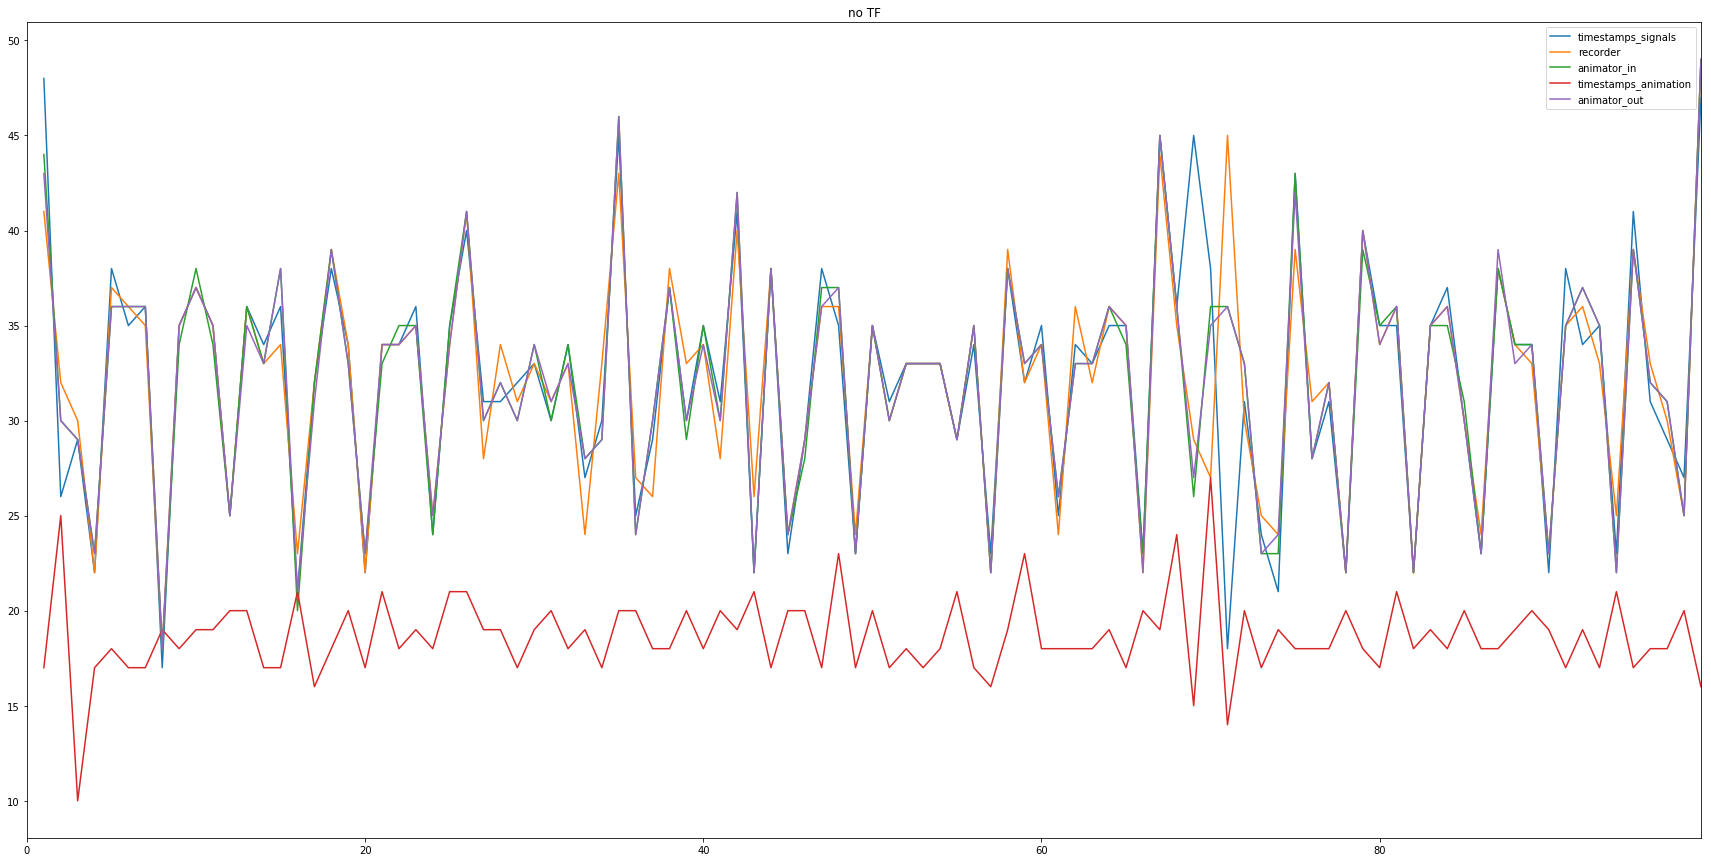

In [85]:
# variance mostly due to recorder
plt.figure(figsize=(30, 15))
df_notf.iloc[:100].diff().plot(ax=plt.gca(), title='no TF');